In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!pip install -q transformers torch sklearn matplotlib seaborn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
# Pip aur setuptools ko pehle upgrade karein taake metadata error na aaye
!pip install --upgrade pip setuptools wheel

# 'sklearn' ki bajaye 'scikit-learn' install karein
!pip install -q transformers torch scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.8 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

...

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Fold 10/10


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



===== TRANSFORMER 10-FOLD RESULTS =====
Accuracy: 96.4509%
F1 Score: 96.1333%
Precision: 95.3028%
Recall: 97.0023%
MCC: 0.9289
Confusion Matrix:
[[2347   98]
 [  61 1974]]
Model saved!
ROC data saved!


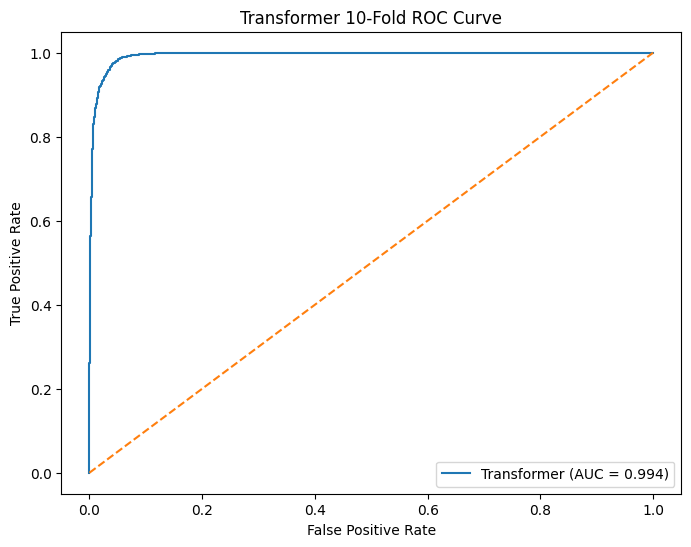

In [ ]:
# =========================
# 1. IMPORTS
# =========================
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, EsmModel
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             matthews_corrcoef, roc_curve, auc)

# =========================
# 2. CONFIG
# =========================
MODEL_NAME_TAG = "transformer10fold_crossvalidation"
MODEL_PATH = MODEL_NAME_TAG + ".pth"
ROC_PATH = "transformer10fold_roc_data.npz"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# =========================
# 3. LOAD DATA
# =========================
def parse_fasta(path):
    seqs = []
    with open(path, 'r') as f:
        current = ""
        for line in f:
            if line.startswith(">"):
                if current:
                    seqs.append(current)
                current = ""
            else:
                current += line.strip()
        if current:
            seqs.append(current)
    return seqs

thermo = parse_fasta('/content/0.6thermo.fasta')
non_thermo = parse_fasta('/content/0.6 non thermo.fasta')

X = np.array(thermo + non_thermo)
y = np.array([1]*len(thermo) + [0]*len(non_thermo))

# =========================
# 4. TOKENIZER
# =========================
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class ProteinDataset(Dataset):
    def __init__(self, seqs, labels):
        self.labels = labels
        self.encodings = tokenizer(list(seqs), padding=True, truncation=True,
                                   max_length=512, return_tensors="pt")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

# =========================
# 5. MODEL
# =========================
class ESMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.esm = EsmModel.from_pretrained(model_name)
        self.classifier = nn.Linear(320, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state.mean(dim=1)
        return self.sigmoid(self.classifier(pooled))

# =========================
# 6. LOAD OR TRAIN
# =========================
if os.path.exists(MODEL_PATH):
    print("Loading saved Transformer model...")
    model = ESMClassifier().to(device)
    model.load_state_dict(torch.load(MODEL_PATH))

else:
    print("Training Transformer with 10-Fold CV...")

    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    acc_list, f1_list, mcc_list = [], [], []
    precision_list, recall_list = [], []
    conf_matrix = np.array([[0,0],[0,0]])

    all_probs = []
    all_true = []

    fold = 1

    for train_idx, test_idx in kf.split(X, y):
        print(f"\nFold {fold}/10")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        train_loader = DataLoader(ProteinDataset(X_train, y_train), batch_size=8, shuffle=True)
        test_loader = DataLoader(ProteinDataset(X_test, y_test), batch_size=8)

        model = ESMClassifier().to(device)
        optimizer = optim.AdamW(model.parameters(), lr=1e-5)
        criterion = nn.BCELoss()

        # TRAIN
        for epoch in range(3):
            model.train()
            for batch in train_loader:
                input_ids = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                optimizer.zero_grad()
                outputs = model(input_ids, mask).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # TEST
        model.eval()
        probs, true = [], []

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)

                outputs = model(input_ids, mask).squeeze()
                probs.extend(outputs.cpu().numpy())
                true.extend(batch['labels'].numpy())

        preds = (np.array(probs) > 0.5).astype(int)

        cm = confusion_matrix(true, preds)
        conf_matrix += cm

        acc_list.append(accuracy_score(true, preds))
        f1_list.append(f1_score(true, preds))
        precision_list.append(precision_score(true, preds))
        recall_list.append(recall_score(true, preds))
        mcc_list.append(matthews_corrcoef(true, preds))

        all_probs.extend(probs)
        all_true.extend(true)

        fold += 1

    # =========================
    # RESULTS
    # =========================
    print("\n===== TRANSFORMER 10-FOLD RESULTS =====")
    print(f"Accuracy: {np.mean(acc_list)*100:.4f}%")
    print(f"F1 Score: {np.mean(f1_list)*100:.4f}%")
    print(f"Precision: {np.mean(precision_list)*100:.4f}%")
    print(f"Recall: {np.mean(recall_list)*100:.4f}%")
    print(f"MCC: {np.mean(mcc_list):.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

    # SAVE MODEL
    torch.save(model.state_dict(), MODEL_PATH)
    print("Model saved!")

    # =========================
    # ROC SAVE
    # =========================
    fpr_transf, tpr_transf, _ = roc_curve(all_true, all_probs)
    auc_transf = auc(fpr_transf, tpr_transf)

    np.savez(ROC_PATH,
             fpr_transf=fpr_transf,
             tpr_transf=tpr_transf,
             auc_transf=auc_transf)

    print("ROC data saved!")

# =========================
# 7. SEPARATE ROC PLOT
# =========================
data = np.load(ROC_PATH)

fpr_transf = data['fpr_transf']
tpr_transf = data['tpr_transf']
auc_transf = data['auc_transf']

plt.figure(figsize=(8,6))
plt.plot(fpr_transf, tpr_transf, label=f'Transformer (AUC = {auc_transf:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Transformer 10-Fold ROC Curve")
plt.legend()
plt.show()

In [ ]:
# =========================
# SAVE ROC DATA
# =========================
np.savez("transformer10fold_roc_data.npz",
         fpr_transf=fpr_transf,
         tpr_transf=tpr_transf,
         auc_transf=auc_transf)

print("ROC data saved as transformer10fold_roc_data.npz")

ROC data saved as transformer10fold_roc_data.npz


In [ ]:
from google.colab import files
files.download("transformer10fold_roc_data.npz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np

data = np.load("transformer10fold_roc_data.npz")

fpr_transf = data['fpr_transf']
tpr_transf = data['tpr_transf']
auc_transf = data['auc_transf']

print("ROC Loaded Successfully!")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(fpr_transf, tpr_transf, label=f'Transformer (AUC = {auc_transf:.3f})')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Transformer ROC Curve (Loaded from NPZ)")
plt.legend()
plt.show()